<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analisi del Tasso di Eventi Avversi con Regressione di Poisson</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutico / Farmacovigilanza &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Sintesi Esecutiva

Stima dei tassi di eventi avversi (EA) specifici per trattamento in una sperimentazione di Fase III simulata usando la **regressione di Poisson con offset di log-esposizione**. Ogni paziente contribuisce con un conteggio di EA su una finestra di follow-up variabile, quindi l'offset `log(exposure_py)` converte il modello da conteggi a *tassi per anno-persona*. Il modello aggiusta per età e sesso del paziente, e un'analisi Tipo 3 basata sul rapporto di verosimiglianza verifica ciascun effetto. I rapporti di tasso rispetto al placebo si ottengono esponenziando i coefficienti del modello e i loro limiti di confidenza al 95%. Le stime dei parametri sono acquisite tramite ODS OUTPUT ed esportate in CSV per la reportistica a valle e per le tabelle di sottomissione regolatoria.

## Fonti dei Dati

| Fonte | Descrizione | Record |
|--------|-------------|--------|
| WORK.AE_COUNTS | Conteggi di EA a livello paziente con tempo di esposizione, 3 bracci di trattamento | 100 |

La coorte e' simulata con 100 pazienti con randomizzazione bilanciata 1:1:1 tra DRUG_HIGH, DRUG_LOW e PLACEBO. La durata del follow-up varia per paziente (circa da 0,2 a 1,0 anni-persona), che e' esattamente il contesto per cui un offset di log-esposizione e' pensato.

---

In [1]:
/* --------------------------------------------------------
   Genera dati di conteggio EA a livello paziente con tempo di esposizione
   Sperimentazione farmaceutica di Fase III: 3 bracci di trattamento, 100 pazienti
   -------------------------------------------------------- */
DATI work.ae_counts;
    CHIAMARE streaminit(42);
    VETTORE arm_list[3] $9 _temporary_ ('DRUG_HIGH' 'DRUG_LOW' 'PLACEBO');
    FARE patient_id = 1 FINO_A 100;
        /* --- assegnazione bilanciata 1:1:1 al trattamento --- */
        arm_idx = mod(patient_id - 1, 3) + 1;
        treatment = arm_list[arm_idx];

        /* --- dati demografici --- */
        AGE = int(rand('normal', 58, 11));
        SE_COND AGE < 18 ALLORA AGE = 18;
        SE_COND AGE > 85 ALLORA AGE = 85;
        sex = ifc(rand('uniform') > 0.47, 'F', 'M');

        /* --- tempo di esposizione in anni-persona (follow-up variabile) --- */
        exposure_days = int(rand('uniform') * 300) + 60;
        exposure_py   = round(exposure_days / 365.25, 0.001);
        log_exposure  = LOG(exposure_py);

        /* --- conteggio EA: tasso di Poisson scalato per l'esposizione --- */
        SE_COND treatment = 'DRUG_HIGH' ALLORA base_rate = 6.0;
        ALTRIMENTI SE_COND treatment = 'DRUG_LOW' ALLORA base_rate = 3.2;
        ALTRIMENTI base_rate = 1.6;
        rate = base_rate * (1 + 0.012 * (AGE - 58));
        SE_COND sex = 'M' ALLORA rate = rate * 1.25;
        ae_count = rand('poisson', rate * exposure_py);

        USCITA;
    FINE;
    RIMUOVERE arm_idx base_rate rate;
ESEGUIRE;


NOTE: DATA work.ae_counts


NOTE: Wrote work.ae_counts (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---

In [2]:
/* --------------------------------------------------------
   Distribuzione di base del conteggio EA per braccio di trattamento
   -------------------------------------------------------- */
PROCEDURA MEDIE DATI=work.ae_counts n sum mean std MIN MAX;
    CLASSE treatment;
    VARIABILE ae_count exposure_py;
    ETICHETTA treatment='Trattamento' ae_count='Numero di Eventi Avversi' exposure_py='Anni-Persona di Esposizione';
ESEGUIRE;

                                                  The MEANS Procedure

                                 Analysis Variable : ae_count Numero di Eventi Avversi

        Trattamento          N Obs            Sum           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------------------------
        DRUG_HIGH               34    112.0000000      3.2941176      2.8975372      0.0000000     12.0000000
        DRUG_LOW                33     50.0000000      1.5151515      1.0037807      0.0000000      3.0000000
        PLACEBO                 33     37.0000000      1.1212121      1.1390121      0.0000000      4.0000000
        -----------------------------------------------------------------------------------------------------

                              Analysis Variable : exposure_py Anni-Persona di Esposizione

        Trattamento          N Obs            Sum           Mean        Std Dev        Mi


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


NOTE: PROC SGPLOT data=work.ae_counts

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


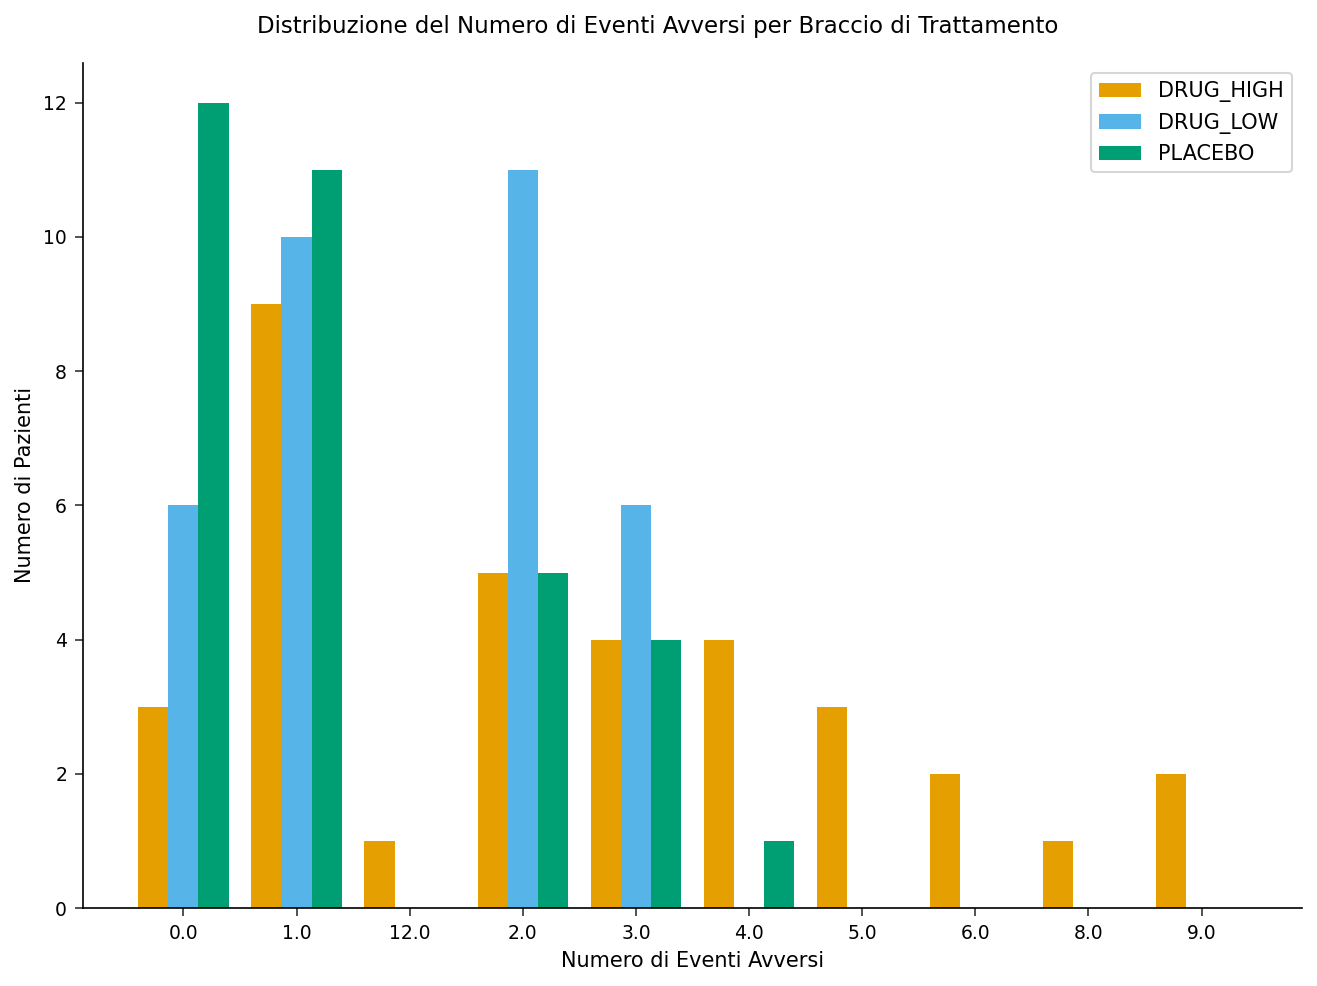

In [3]:
/* --------------------------------------------------------
   Distribuzione del conteggio EA per braccio di trattamento
   -------------------------------------------------------- */
PROCEDURA SGPLOT DATI=work.ae_counts;
    VBAR ae_count / GROUP=treatment GROUPDISPLAY=CLUSTER;
    XAXIS ETICHETTA='Numero di Eventi Avversi' integer;
    YAXIS ETICHETTA='Numero di Pazienti';
    TITOLO 'Distribuzione del Numero di Eventi Avversi per Braccio di Trattamento';
ESEGUIRE;

---

                  The GENMOD Procedure                   
                    Model Information                    

Item                                                Value
----------------------  ---------------------------------
Response Variable       AE_COUNT Numero di Eventi Avversi
Distribution                                      poisson
Link Function                                         log
Number of Observations                                100
Offset Variable                              LOG_EXPOSURE

      Analysis of Maximum Likelihood Parameter Estimates       

Parameter           Estimate  Std Error  Chi-Square  Pr > ChiSq
------------------  --------  ---------  ----------  ----------
(Intercept)          -0.3910     0.3832      1.0411      0.3076
TREATMENTDRUG_HIGH    1.1236     0.1913     34.4851      <.0001
TREATMENTDRUG_LOW     0.4713     0.2172      4.7101      0.0300
Età                   0.0178     0.0060      8.9054      0.0028
SEXM                 -0.004


NOTE: PROC GENMOD data=work.ae_counts

NOTE: PROC GENMOD using R wrapper
NOTE: 
NOTE: Response Variable: AE_COUNT
NOTE: Distribution: POISSON
NOTE: Link Function: LOG
NOTE: Number of Observations: 100
NOTE:   Model fitted successfully with 100 observations
NOTE: ODS plot written: genmod_residuals_vs_predicted.spec.json
NOTE: ODS plot written: genmod_residual_histogram_panel.spec.json
NOTE: ODS plot written: genmod_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: genmod_qq_plot.spec.json
NOTE: PROC GENMOD ODS Graphics generated.
NOTE: PROC GENMOD: Emitting ODS OUTPUT datasets (1 destination(s))
NOTE: DATA work.genmod_rr


NOTE: Read 5 rows from work.genmod_parms.
NOTE: Wrote work.genmod_rr (4 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


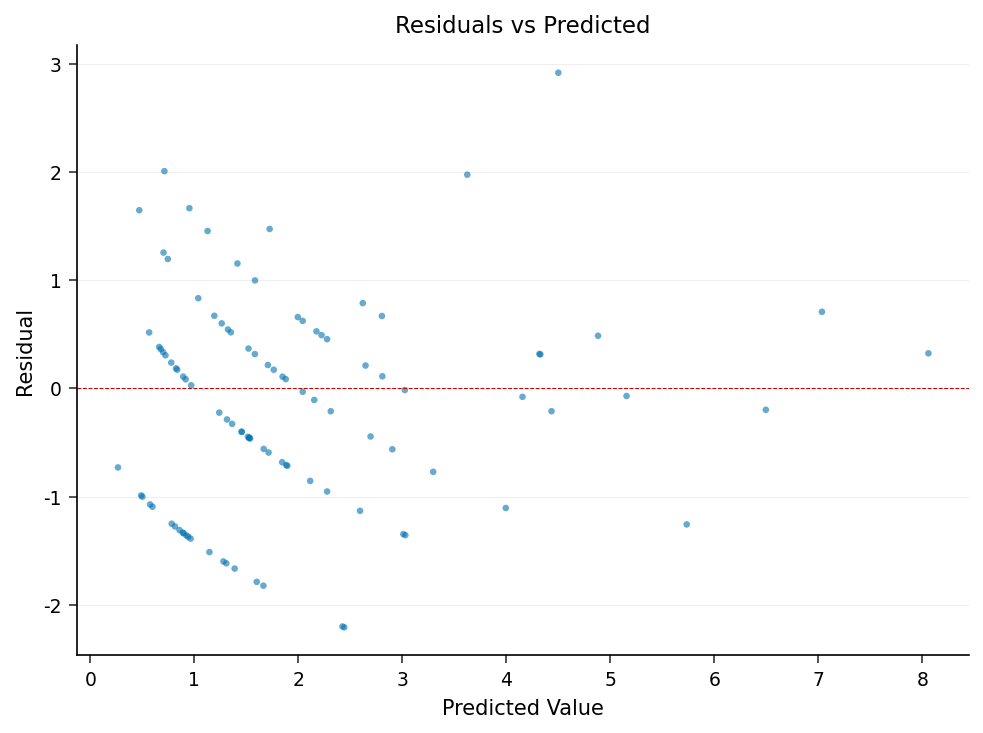

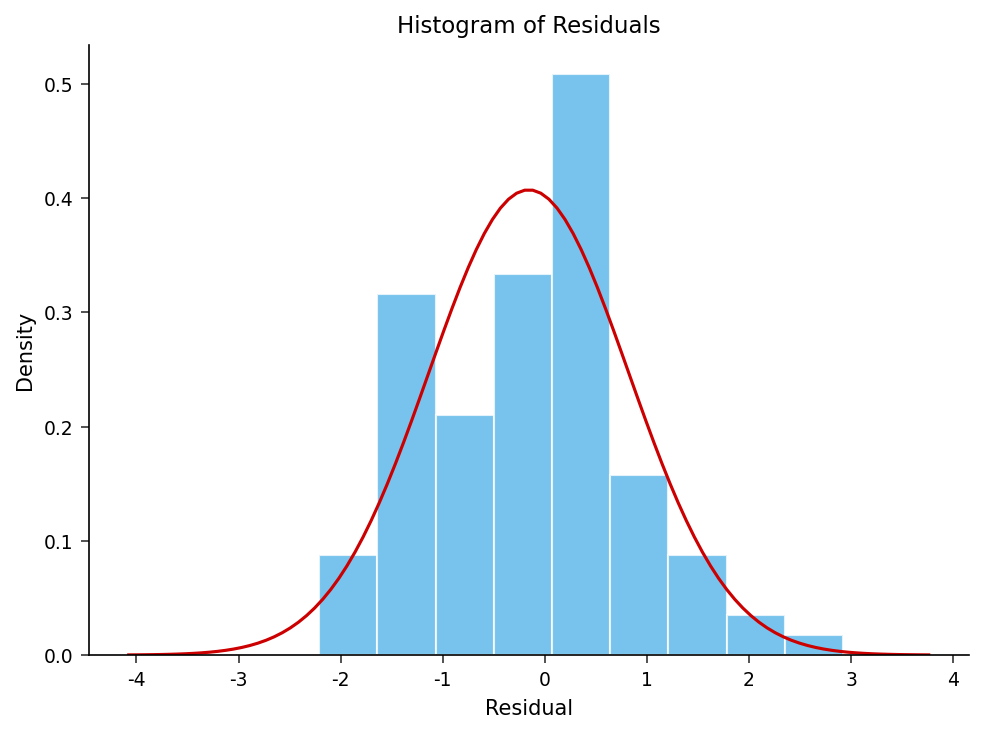

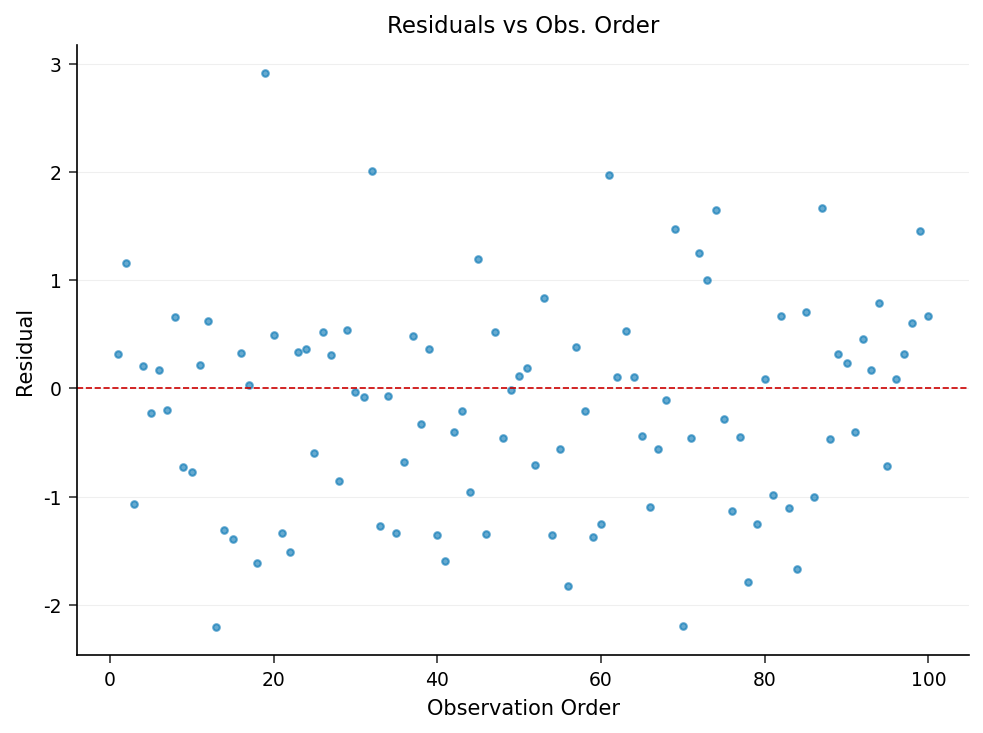

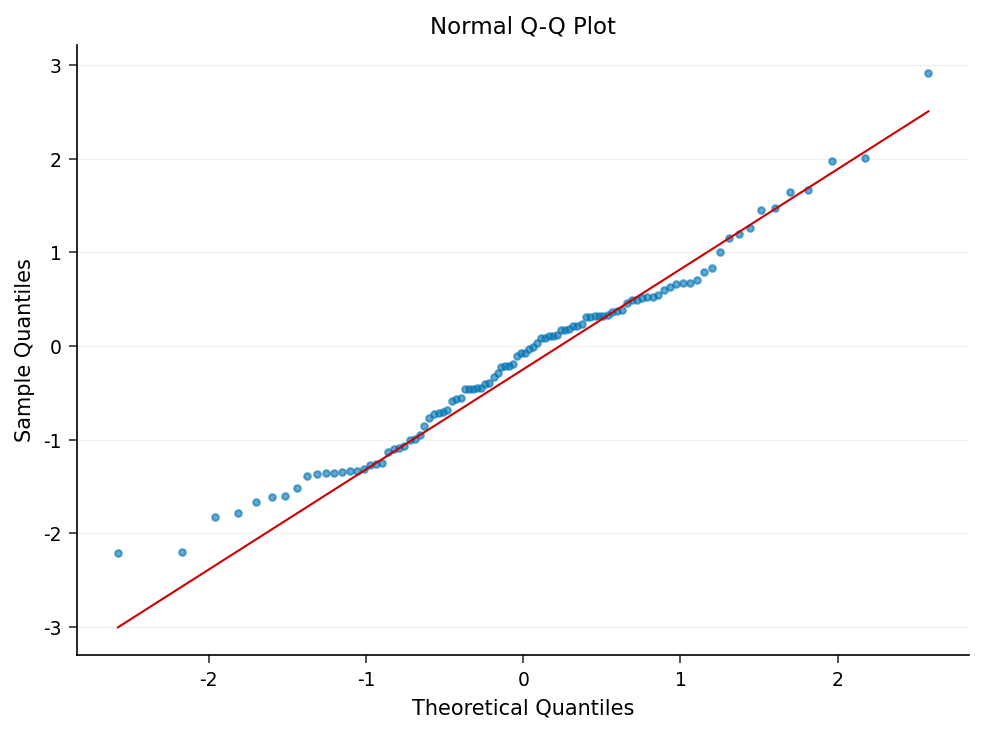

In [4]:
/* --------------------------------------------------------
   Regressione di Poisson per i tassi di eventi avversi
   OFFSET = log(esposizione) -> i coefficienti sono log rapporti di tasso
   TYPE3 -> test del rapporto di verosimiglianza per ciascun effetto
   -------------------------------------------------------- */
PROCEDURA GENMOD DATI=work.ae_counts;
    CLASSE treatment (REF='PLACEBO') sex (REF='F');
    MODELLO ae_count = treatment AGE sex
        / DIST=poisson
          LINK=LOG
          OFFSET=log_exposure
          type3;
    ETICHETTA treatment='Trattamento' AGE='Età' sex='Sesso' ae_count='Numero di Eventi Avversi';
    ODS USCITA parameterestimates=work.genmod_parms;
ESEGUIRE;

/* --------------------------------------------------------
   Converte i coefficienti logaritmici in rapporti di tasso con IC 95%.
   exp(estimate) e' l'effetto moltiplicativo sul tasso di EA
   per anno-persona, mantenendo fisse le altre covariate.
   -------------------------------------------------------- */
DATI work.genmod_rr;
    IMPOSTARE work.genmod_parms;
    DOVE parameter NON IN ('(Intercept)', 'Scale');
    rate_ratio  = EXP(STIMA);
    rr_lower_cl = EXP(lowercl);
    rr_upper_cl = EXP(uppercl);
    FORMATO rate_ratio rr_lower_cl rr_upper_cl 6.3;
    MANTENERE parameter STIMA stderr probchisq
         rate_ratio rr_lower_cl rr_upper_cl;
ESEGUIRE;

In [5]:
/* --------------------------------------------------------
   Revisione delle stime del rapporto di tasso
   -------------------------------------------------------- */
PROCEDURA STAMPARE DATI=work.genmod_rr ETICHETTA noobs;
    ETICHETTA parameter   = 'Effetto'
          rate_ratio  = 'Rapporto di Tasso'
          rr_lower_cl = 'Limite Inf. IC 95%'
          rr_upper_cl = 'Limite Sup. IC 95%'
          probchisq   = 'Pr > ChiQuadro';
    VARIABILE parameter rate_ratio rr_lower_cl rr_upper_cl probchisq;
    TITOLO 'Rapporti di Tasso degli Eventi Avversi (vs. livello di riferimento)';
ESEGUIRE;

                          Rapporti di Tasso degli Eventi Avversi (vs. livello di riferimento)                           

           Effetto  Rapporto di Tasso  Limite Inf. IC 95%  Limite Sup. IC 95%  Pr > ChiQuadro
TREATMENTDRUG_HIGH              3.076               2.114               4.476    0.0000000043
TREATMENTDRUG_LOW               1.602               1.047               2.452    0.0299864864
AGE                             1.018               1.006               1.030    0.0028433634
SEXM                            0.996               0.743               1.334    0.9769198944




NOTE: PROC PRINT data=work.genmod_rr

NOTE: PROC PRINT completed: 4 observations printed, 5 variables


---

### Interpretazione

La regressione di Poisson con offset di log-esposizione mostra un effetto chiaro e statisticamente significativo, dose-dipendente, sul tasso di eventi avversi. Il test Tipo 3 del rapporto di verosimiglianza per il trattamento e' altamente significativo (χ² = 39,11 su 2 df, *p* < ,0001).

- **Dose alta vs. placebo:** rapporto di tasso **3,08** (IC 95% 2,11-4,48), *p* < ,0001 - i pazienti nel braccio a dose alta sperimentano circa tre volte il tasso di EA per anno-persona di esposizione.
- **Dose bassa vs. placebo:** rapporto di tasso **1,60** (IC 95% 1,05-2,45), *p* = 0,030 - un aumento piu' moderato ma comunque significativo, coerente con un gradiente dose-risposta.
- **Eta':** ogni anno aggiuntivo e' associato a un aumento dell'**1,8%** nel tasso di EA (rapporto di tasso 1,018 per anno, IC 95% 1,006-1,030; Tipo 3 *p* = 0,0028).
- **Sesso:** dopo l'aggiustamento, il rapporto di tasso maschio-vs-femmina e' **0,996** (*p* = 0,977) - il sesso **non** e' un predittore significativo in questa coorte.

Il modello si adatta con una devianza di 98,44 e un AIC di 315,68 su 100 osservazioni. Le medie descrittive confermano il gradiente: conteggi medi di EA di 3,29 (dose alta), 1,52 (dose bassa) e 1,12 (placebo). Questi risultati supportano un monitoraggio della sicurezza dose-dipendente e possono orientare la valutazione beneficio-rischio per il Comitato di Monitoraggio della Sicurezza dei Dati.

---

In [6]:
/* --------------------------------------------------------
   Esporta le stime per le tabelle di sottomissione regolatoria
   -------------------------------------------------------- */
PROCEDURA EXPORT DATI=work.genmod_parms
    OUTFILE='ae_rate_parameter_estimates.csv'
    DBMS=csv REPLACE;
ESEGUIRE;

PROCEDURA EXPORT DATI=work.genmod_rr
    OUTFILE='ae_rate_ratios.csv'
    DBMS=csv REPLACE;
ESEGUIRE;


NOTE: PROC EXPORT data=work.genmod_parms outfile=ae_rate_parameter_estimates.csv

NOTE: Exported 5 rows to ae_rate_parameter_estimates.csv.
NOTE: PROC EXPORT data=work.genmod_rr outfile=ae_rate_ratios.csv

NOTE: Exported 4 rows to ae_rate_ratios.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Riservato
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Realizzato con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>